# 🛒 E-Commerce Customer Analysis — India (Flipkart)
### Data Loading → Cleaning → EDA (10 Charts) → Customer Insights

| | |
|---|---|
| **Student Name** | Misti Chatterjee |
| **Project Title** | E-Commerce Customer Analysis |
| **Dataset** | Flipkart Products Review Dataset (India) |
| **Domain** | E-Commerce / Customer Behavior |
| **Tools** | Python · Pandas · NumPy · Matplotlib · Seaborn |

>  **Objective:** Analyze Flipkart product categories, customer reviews, ratings, and shopping patterns.

**Tasks Covered:**
-  Handle missing customer data
-  Analyze customer purchase behavior
-  Visualize order distribution
-  Study rating trends
-  Generate customer insights
---

## Section 1 — Kaggle Credentials (Edit Only This Cell)

In [32]:
KAGGLE_USERNAME = "mistichatterjee29"
KAGGLE_KEY      = "KGAT_1512c26a5452ba331b1e0ebd2c351060"

import os, json, pathlib

os.environ["KAGGLE_USERNAME"] = KAGGLE_USERNAME
os.environ["KAGGLE_KEY"]      = KAGGLE_KEY

kaggle_dir = pathlib.Path.home() / ".kaggle"
kaggle_dir.mkdir(exist_ok=True)
kaggle_json = kaggle_dir / "kaggle.json"
kaggle_json.write_text(json.dumps({"username": KAGGLE_USERNAME, "key": KAGGLE_KEY}))
kaggle_json.chmod(0o600)

print(" Kaggle credentials set")
print(f"  Username : {KAGGLE_USERNAME}")


 Kaggle credentials set
  Username : mistichatterjee29


##  Section 2 — Install Libraries & Download Dataset

In [33]:
!pip install -q kaggle pandas numpy matplotlib seaborn
print("Libraries installed")


Libraries installed


In [34]:
import os

DATASET  = "mansithummar67/flipkart-product-review-dataset"
DATA_DIR = "./data"
os.makedirs(DATA_DIR, exist_ok=True)

print(f"Downloading: {DATASET}")
os.system(f"kaggle datasets download -d {DATASET} --unzip -p {DATA_DIR}")

for f in os.listdir(DATA_DIR):
    size_kb = os.path.getsize(f"{DATA_DIR}/{f}") / 1024
    print(f"  {f}  ({size_kb:.1f} KB)")
print("✓ Download complete")


Downloading: mansithummar67/flipkart-product-review-dataset
  flipkart_product.csv  (29070.1 KB)
✓ Download complete


##  Section 3 — Imports & Configuration

In [35]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings, os, glob

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 20)
pd.set_option("display.float_format", "{:.2f}".format)

CLR_PRIMARY   = "#FF6600"   # Flipkart orange
CLR_SECONDARY = "#2874F0"   # Flipkart blue
CLR_ACCENT    = "#388E3C"
CLR_WARNING   = "#E53935"
CLR_SUCCESS   = "#7DC67D"
PALETTE       = sns.color_palette("Set2", 8)

plt.rcParams.update({
    "figure.dpi"       : 130,
    "axes.spines.top"  : False,
    "axes.spines.right": False,
})

CHARTS_DIR  = "./charts"
OUTPUTS_DIR = "./outputs"
os.makedirs(CHARTS_DIR,  exist_ok=True)
os.makedirs(OUTPUTS_DIR, exist_ok=True)

print(" All imports done")


 All imports done


## Section 4 — Raw Data Ingestion & First Look

In [36]:
csv_files = glob.glob("./data/*.csv")
if not csv_files:
    raise FileNotFoundError("No CSV in ./data/ — check Section 1 credentials.")

CSV_PATH = csv_files[0]
print(f"Loading: {CSV_PATH}")

df_raw = pd.read_csv(CSV_PATH, encoding="unicode_escape")

print("=" * 55)
print(f"  SHAPE : {df_raw.shape[0]:,} rows × {df_raw.shape[1]} columns")
print("=" * 55)
df_raw.head(8)


Loading: ./data/flipkart_product.csv
  SHAPE : 189,874 rows × 5 columns


,ProductName,Price,Rate,Review,Summary
0,Candes 12 L Room/Personal Air Cooler?ÿ?ÿ(White...,"??3,999",5,Super!,Great cooler.. excellent air flow and for this...
1,Candes 12 L Room/Personal Air Cooler?ÿ?ÿ(White...,"??3,999",5,Awesome,Best budget 2 fit cooler. Nice cooling
2,Candes 12 L Room/Personal Air Cooler?ÿ?ÿ(White...,"??3,999",3,Fair,The quality is good but the power of air is de...
3,Candes 12 L Room/Personal Air Cooler?ÿ?ÿ(White...,"??3,999",1,Useless product,Very bad product it's a only a fan
4,Candes 12 L Room/Personal Air Cooler?ÿ?ÿ(White...,"??3,999",3,Fair,Ok ok product
5,Candes 12 L Room/Personal Air Cooler?ÿ?ÿ(White...,"??3,999",5,Awesome,The cooler is really fantastic and provides go...
6,Candes 12 L Room/Personal Air Cooler?ÿ?ÿ(White...,"??3,999",5,Highly recommended,Very good product
7,Candes 12 L Room/Personal Air Cooler?ÿ?ÿ(White...,"??3,999",3,Nice,Very nice


In [37]:
print(f"{'Column':<25} {'Dtype':<15} {'Unique':>8} {'Nulls':>8}")
print("-" * 60)
for col in df_raw.columns:
    print(f"  {col:<23} {str(df_raw[col].dtype):<15} "
          f"{df_raw[col].nunique():>8} {df_raw[col].isnull().sum():>8}")


Column                    Dtype             Unique    Nulls
------------------------------------------------------------
  ProductName             object               812        0
  Price                   object               561        1
  Rate                    object                 9        1
  Review                  object              1264        4
  Summary                 object             98343       14


In [38]:
df_raw.describe(include='all').T

,count,unique,top,freq
ProductName,189874,812,MILTON Thermosteel Flip Lid 500 ml FlaskÂ Â (P...,9278
Price,189873,561,"â¹1,299",10005
Rate,189873,9,5,108694
Review,189870,1264,Nan,20862
Summary,189860,98343,Good,14175


**bold text**##  Section 5 — Data Cleaning & Preprocessing
> **Task:** Handle missing data, fix data types, remove duplicates.

In [39]:
df = df_raw.copy()

# ── 5.1 Rename columns for easier access ─────────────────────────────────────
df.columns = [c.strip().replace(" ","_").lower() for c in df.columns]
print("Columns after rename:", list(df.columns))


Columns after rename: ['productname', 'price', 'rate', 'review', 'summary']


In [40]:
# ── 5.2 Missing value report ─────────────────────────────────────────────────
missing     = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df  = pd.DataFrame({"Missing Count": missing, "Missing %": missing_pct})
missing_df  = missing_df[missing_df["Missing Count"] > 0].sort_values("Missing %", ascending=False)

print("=== MISSING VALUE REPORT ===")
print(missing_df.to_string() if not missing_df.empty else "No missing values!")
print(f"\nTotal missing cells: {df.isnull().sum().sum():,}")


=== MISSING VALUE REPORT ===
         Missing Count  Missing %
summary             14       0.01
price                1       0.00
rate                 1       0.00
review               4       0.00

Total missing cells: 20


In [41]:
# ── 5.3 Drop rows with missing product name or rating ────────────────────────
before = len(df)
rating_col   = [c for c in df.columns if "rate" in c or "rating" in c][0]
product_col  = [c for c in df.columns if "product" in c or "name" in c][0]
review_col   = [c for c in df.columns if "review" in c or "summary" in c or "comment" in c][0]

print(f"Rating column  : {rating_col}")
print(f"Product column : {product_col}")
print(f"Review column  : {review_col}")

df.dropna(subset=[product_col, rating_col], inplace=True)
print(f"\n Dropped {before - len(df):,} rows with missing product/rating")

# ── 5.4 Remove duplicates ────────────────────────────────────────────────────
n_dup = df.duplicated().sum()
df.drop_duplicates(inplace=True)
print(f" Removed {n_dup:,} duplicate rows")

# ── 5.5 Clean rating column → numeric ────────────────────────────────────────
df[rating_col] = pd.to_numeric(df[rating_col].astype(str)
                                .str.extract(r"(\d+\.?\d*)")[0], errors="coerce")
df.dropna(subset=[rating_col], inplace=True)
df = df[df[rating_col].between(1, 5)]
print(f" Cleaned rating column — range: {df[rating_col].min()} – {df[rating_col].max()}")

print(f"\n── CLEANING COMPLETE ──────────────────────────────────")
print(f"  Final shape     : {df.shape}")
print(f"  Nulls remaining : {df.isnull().sum().sum()}")
print(f"  Unique products : {df[product_col].nunique():,}")
print(f"  Avg rating      : {df[rating_col].mean():.2f} / 5")


Rating column  : rate
Product column : productname
Review column  : review

 Dropped 1 rows with missing product/rating
 Removed 24,861 duplicate rows
 Cleaned rating column — range: 1.0 – 5.0

── CLEANING COMPLETE ──────────────────────────────────
  Final shape     : (165010, 5)
  Nulls remaining : 8
  Unique products : 811
  Avg rating      : 4.07 / 5


##  Section 6 — Exploratory Data Analysis (10 Charts)
> **Tasks:** Analyze purchase behavior · Visualize distributions · Study rating trends

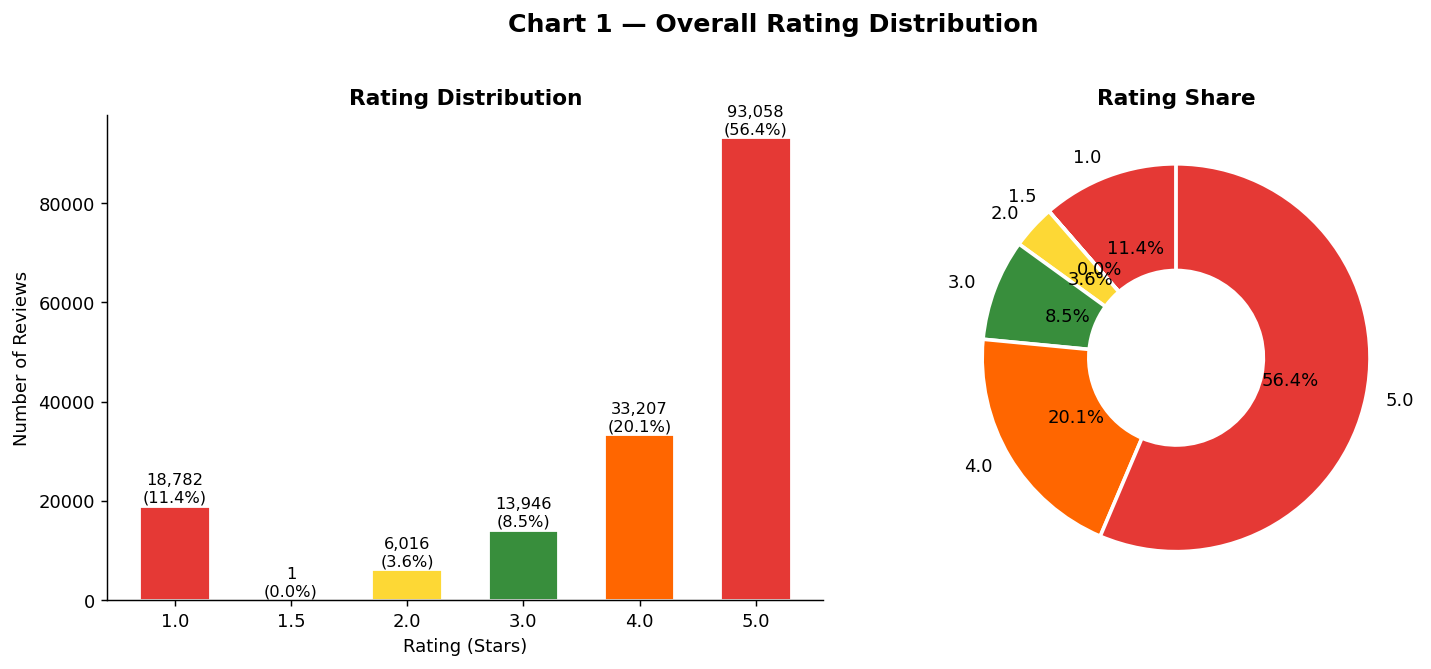

Average Rating : 4.07 / 5
5-star reviews : 93,058 (56.4%)
1-star reviews : 18,782 (11.4%)


In [42]:
# ── Chart 1 : Overall Rating Distribution ────────────────────────────────────
rating_counts = df[rating_col].value_counts().sort_index()

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

bar_colors = [CLR_WARNING, "#FF8F00", "#FDD835", CLR_ACCENT, CLR_PRIMARY]
axes[0].bar(rating_counts.index.astype(str), rating_counts.values,
            color=bar_colors, edgecolor="white", width=0.6)
axes[0].set_xlabel("Rating (Stars)")
axes[0].set_ylabel("Number of Reviews")
axes[0].set_title("Rating Distribution", fontsize=12, fontweight="bold")
for i, v in enumerate(rating_counts.values):
    axes[0].text(i, v + rating_counts.max()*0.01,
                 f"{v:,}\n({v/len(df)*100:.1f}%)", ha="center", fontsize=9)

axes[1].pie(rating_counts.values, labels=[f"{r}" for r in rating_counts.index],
            autopct="%1.1f%%", startangle=90, colors=bar_colors,
            wedgeprops=dict(width=0.55, edgecolor="white", linewidth=2))
axes[1].set_title("Rating Share", fontsize=12, fontweight="bold")

plt.suptitle("Chart 1 — Overall Rating Distribution", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig(f"{CHARTS_DIR}/chart_01_rating_distribution.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Average Rating : {df[rating_col].mean():.2f} / 5")
print(f"5-star reviews : {(df[rating_col]==5).sum():,} ({(df[rating_col]==5).mean()*100:.1f}%)")
print(f"1-star reviews : {(df[rating_col]==1).sum():,} ({(df[rating_col]==1).mean()*100:.1f}%)")


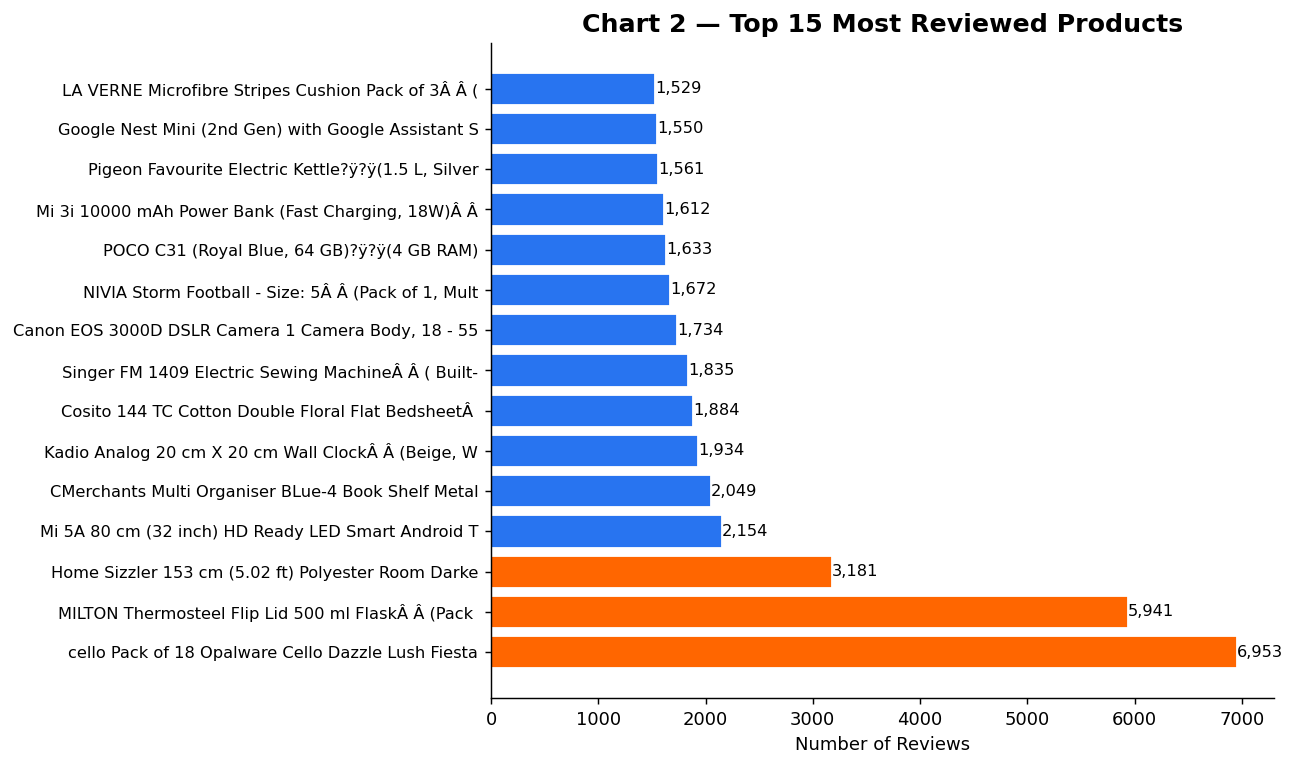

In [43]:
# ── Chart 2 : Top 15 Most Reviewed Products ──────────────────────────────────
top_reviewed = df[product_col].value_counts().head(15)

fig, ax = plt.subplots(figsize=(10, 6))
colors_bar = [CLR_PRIMARY if i < 3 else CLR_SECONDARY for i in range(len(top_reviewed))]
ax.barh(range(len(top_reviewed)), top_reviewed.values, color=colors_bar, edgecolor="white")
ax.set_yticks(range(len(top_reviewed)))
ax.set_yticklabels([t[:50] for t in top_reviewed.index], fontsize=9)
ax.set_xlabel("Number of Reviews")
ax.set_title("Chart 2 — Top 15 Most Reviewed Products", fontsize=14, fontweight="bold")
for i, v in enumerate(top_reviewed.values):
    ax.text(v + 0.5, i, f"{v:,}", va="center", fontsize=9)
plt.tight_layout()
plt.savefig(f"{CHARTS_DIR}/chart_02_top_reviewed.png", dpi=150, bbox_inches="tight")
plt.show()


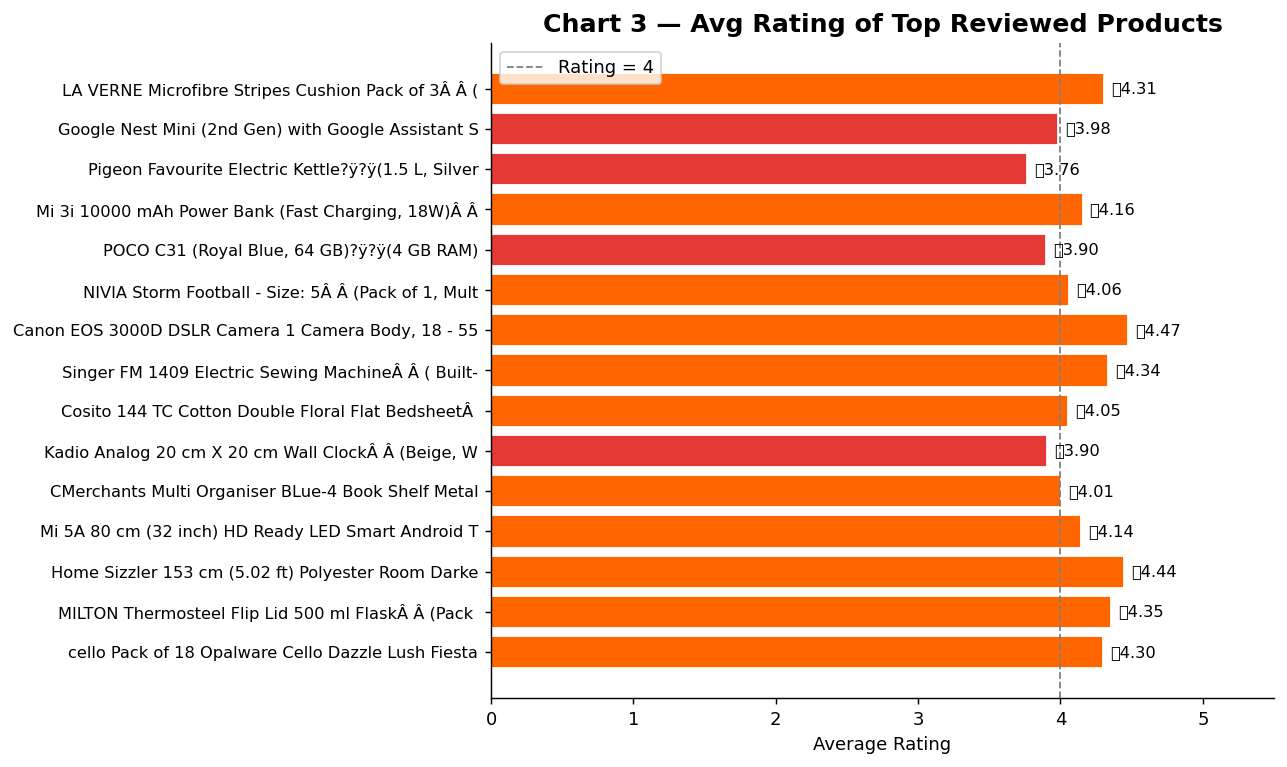

In [44]:
# ── Chart 3 : Average Rating per Top 15 Products ─────────────────────────────
top_products_list = top_reviewed.index.tolist()
prod_avg_rating   = (df[df[product_col].isin(top_products_list)]
                       .groupby(product_col)[rating_col]
                       .mean().reindex(top_products_list))

fig, ax = plt.subplots(figsize=(10, 6))
colors_rating = [CLR_PRIMARY if v >= 4 else CLR_WARNING if v >= 3 else CLR_WARNING
                 for v in prod_avg_rating.values]
bars = ax.barh(range(len(prod_avg_rating)), prod_avg_rating.values,
               color=colors_rating, edgecolor="white")
ax.set_yticks(range(len(prod_avg_rating)))
ax.set_yticklabels([t[:50] for t in prod_avg_rating.index], fontsize=9)
ax.set_xlabel("Average Rating")
ax.set_xlim(0, 5.5)
ax.axvline(4, color="gray", lw=1, linestyle="--", label="Rating = 4")
ax.set_title("Chart 3 — Avg Rating of Top Reviewed Products", fontsize=14, fontweight="bold")
ax.legend()
for i, v in enumerate(prod_avg_rating.values):
    ax.text(v + 0.05, i, f"⭐{v:.2f}", va="center", fontsize=9)
plt.tight_layout()
plt.savefig(f"{CHARTS_DIR}/chart_03_avg_rating_products.png", dpi=150, bbox_inches="tight")
plt.show()


Category column candidates: []
Using column: Category


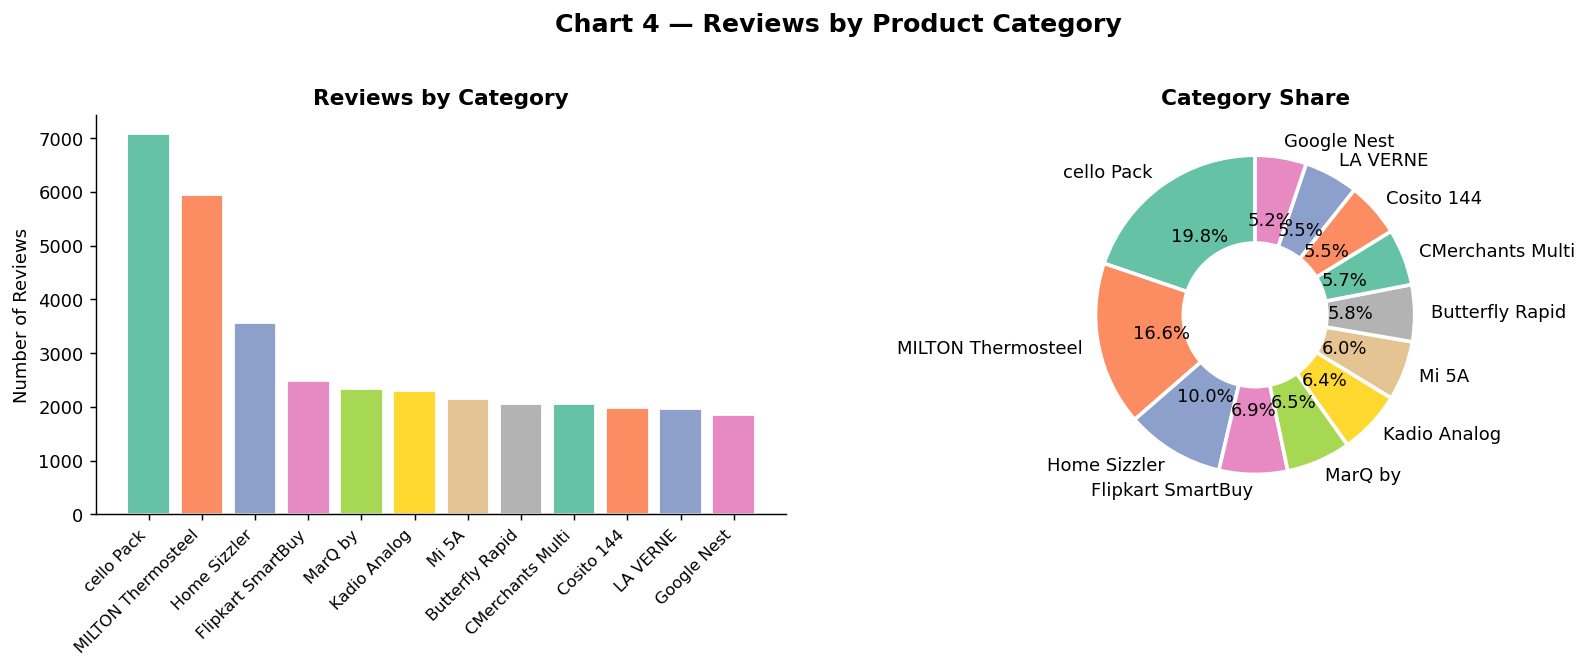

In [45]:
# ── Chart 4 : Category-wise Review Count ─────────────────────────────────────
# Find category column
cat_col_candidates = [c for c in df.columns if "categ" in c or "type" in c or "brand" in c]
print("Category column candidates:", cat_col_candidates)

# Use first found, or product column grouped by prefix if none
if cat_col_candidates:
    cat_col = cat_col_candidates[0]
else:
    # Extract category from product name (first 2 words)
    df["Category"] = df[product_col].str.split().str[:2].str.join(" ")
    cat_col = "Category"

print(f"Using column: {cat_col}")
cat_counts = df[cat_col].value_counts().head(12)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].bar(range(len(cat_counts)), cat_counts.values,
            color=PALETTE[:len(cat_counts)], edgecolor="white")
axes[0].set_xticks(range(len(cat_counts)))
axes[0].set_xticklabels([t[:20] for t in cat_counts.index], rotation=45, ha="right", fontsize=9)
axes[0].set_ylabel("Number of Reviews")
axes[0].set_title("Reviews by Category", fontsize=12, fontweight="bold")

axes[1].pie(cat_counts.values, labels=[t[:20] for t in cat_counts.index],
            autopct="%1.1f%%", startangle=90, colors=PALETTE[:len(cat_counts)],
            wedgeprops=dict(width=0.55, edgecolor="white", linewidth=2))
axes[1].set_title("Category Share", fontsize=12, fontweight="bold")

plt.suptitle("Chart 4 — Reviews by Product Category", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig(f"{CHARTS_DIR}/chart_04_category_distribution.png", dpi=150, bbox_inches="tight")
plt.show()


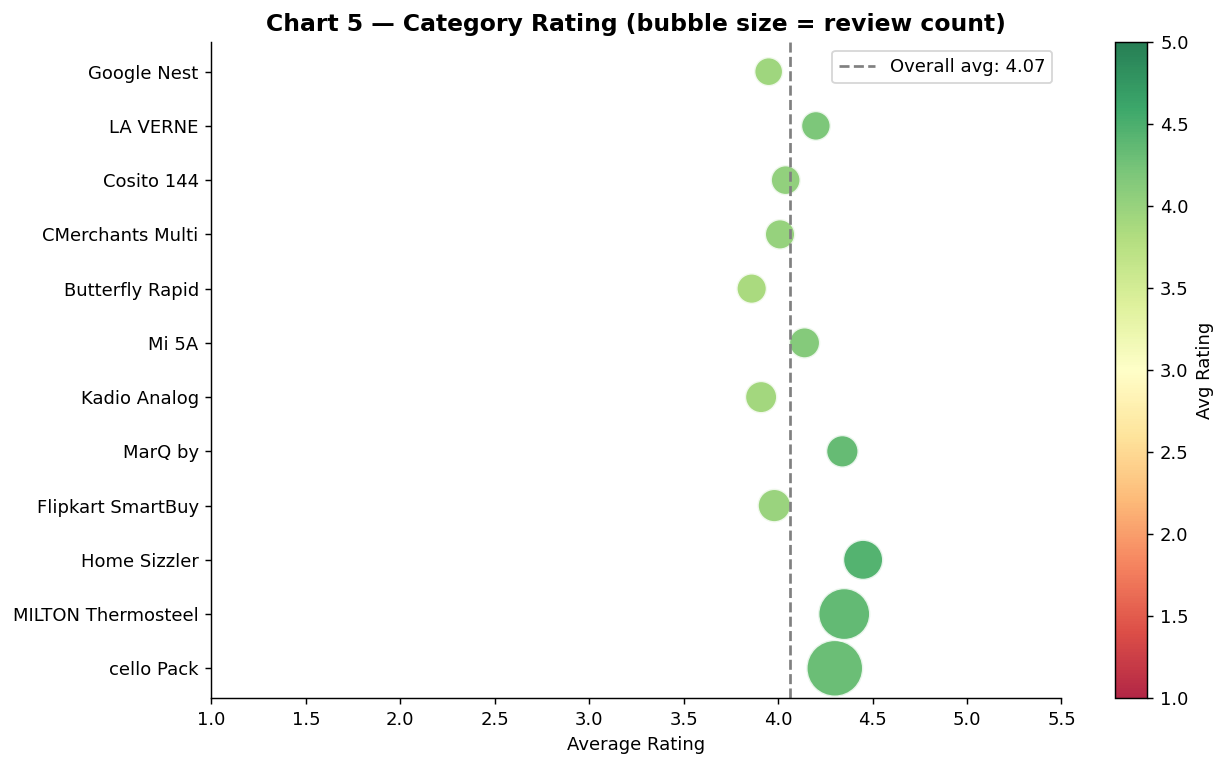

In [46]:
# ── Chart 5 : Category-wise Average Rating (Heatmap style) ──────────────────
cat_rating = (df.groupby(cat_col)[rating_col]
                .agg(["mean","count"])
                .rename(columns={"mean":"Avg_Rating","count":"Review_Count"})
                .sort_values("Review_Count", ascending=False)
                .head(12))
cat_rating["Avg_Rating"] = cat_rating["Avg_Rating"].round(2)

fig, ax = plt.subplots(figsize=(10, 6))
scatter = ax.scatter(cat_rating["Avg_Rating"], range(len(cat_rating)),
                     s=cat_rating["Review_Count"]/cat_rating["Review_Count"].max()*1000,
                     c=cat_rating["Avg_Rating"], cmap="RdYlGn", vmin=1, vmax=5,
                     edgecolors="white", linewidths=1.5, alpha=0.85)
ax.set_yticks(range(len(cat_rating)))
ax.set_yticklabels([t[:30] for t in cat_rating.index], fontsize=10)
ax.set_xlabel("Average Rating")
ax.set_xlim(1, 5.5)
ax.axvline(df[rating_col].mean(), color="gray", lw=1.5, linestyle="--",
           label=f"Overall avg: {df[rating_col].mean():.2f}")
ax.set_title("Chart 5 — Category Rating (bubble size = review count)",
             fontsize=13, fontweight="bold")
ax.legend()
plt.colorbar(scatter, ax=ax, label="Avg Rating")
plt.tight_layout()
plt.savefig(f"{CHARTS_DIR}/chart_05_category_ratings.png", dpi=150, bbox_inches="tight")
plt.show()


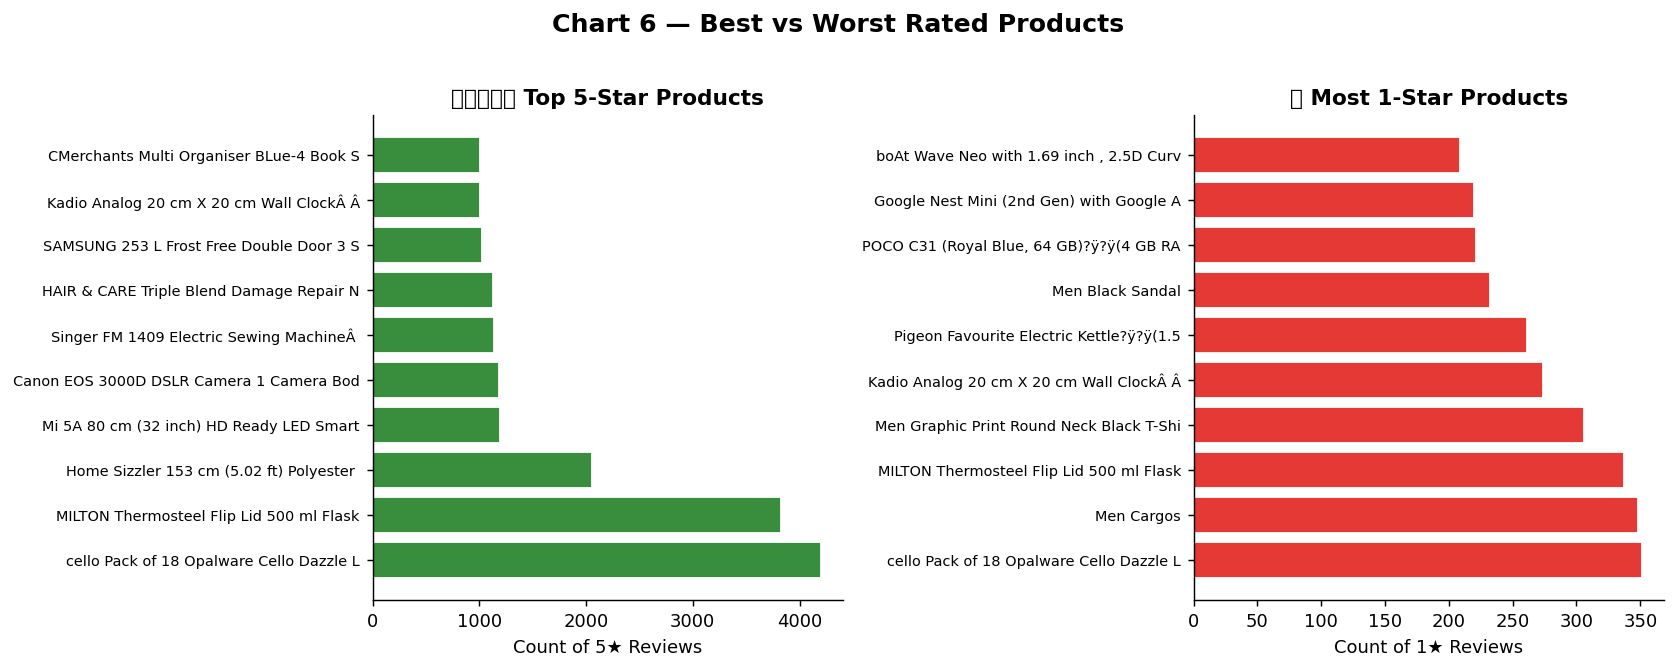

In [47]:
# ── Chart 6 : Rating Trend — 5★ vs 1★ Products ───────────────────────────────
five_star = df[df[rating_col] == 5][product_col].value_counts().head(10)
one_star  = df[df[rating_col] == 1][product_col].value_counts().head(10)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].barh(range(len(five_star)), five_star.values, color=CLR_ACCENT, edgecolor="white")
axes[0].set_yticks(range(len(five_star)))
axes[0].set_yticklabels([t[:40] for t in five_star.index], fontsize=8)
axes[0].set_xlabel("Count of 5★ Reviews")
axes[0].set_title("⭐⭐⭐⭐⭐ Top 5-Star Products", fontsize=12, fontweight="bold")

axes[1].barh(range(len(one_star)), one_star.values, color=CLR_WARNING, edgecolor="white")
axes[1].set_yticks(range(len(one_star)))
axes[1].set_yticklabels([t[:40] for t in one_star.index], fontsize=8)
axes[1].set_xlabel("Count of 1★ Reviews")
axes[1].set_title("⭐ Most 1-Star Products", fontsize=12, fontweight="bold")

plt.suptitle("Chart 6 — Best vs Worst Rated Products", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig(f"{CHARTS_DIR}/chart_06_best_worst.png", dpi=150, bbox_inches="tight")
plt.show()


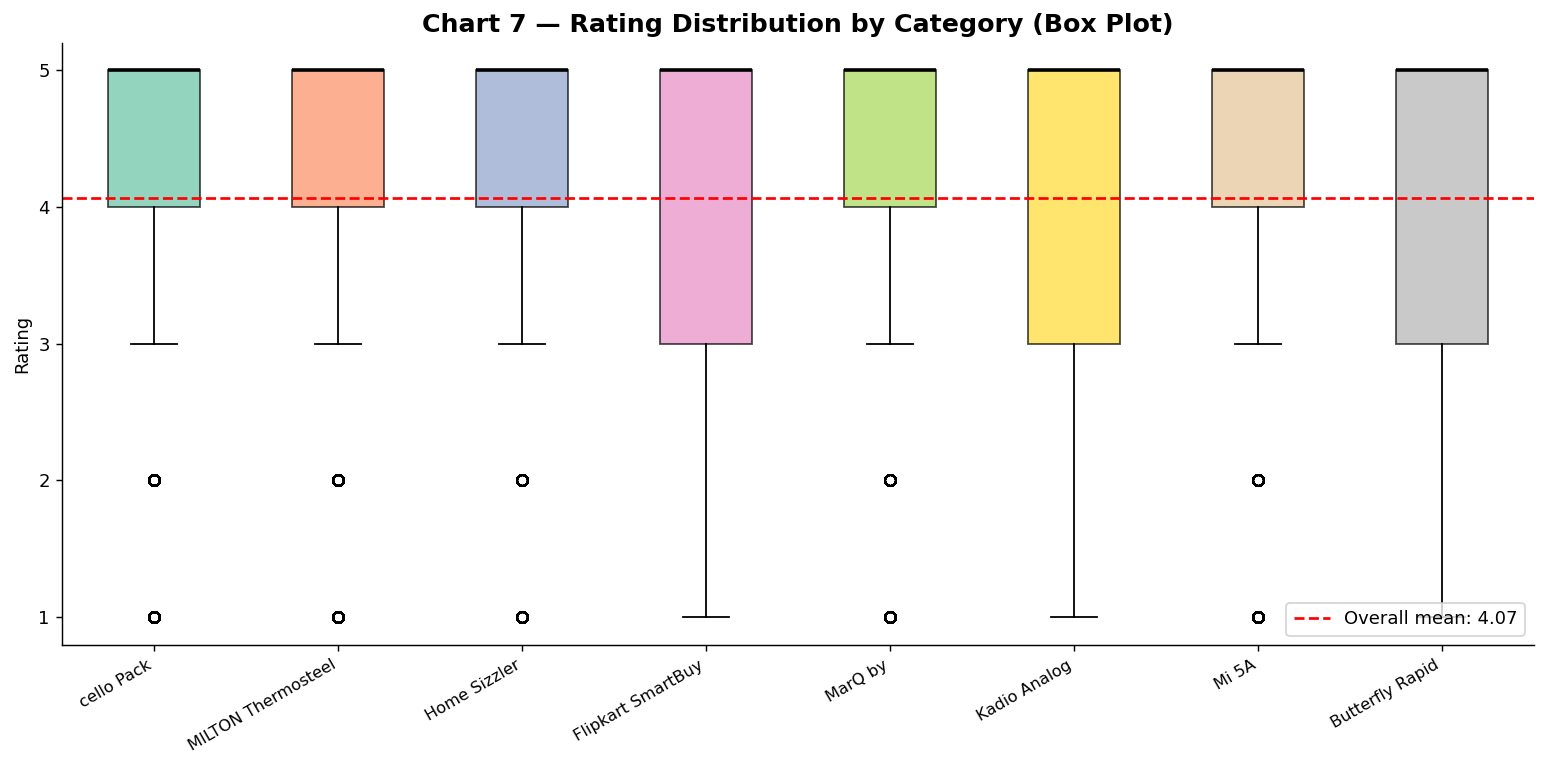

In [48]:
# ── Chart 7 : Rating Score Distribution per Category (Box Plot) ──────────────
top_cats = df[cat_col].value_counts().head(8).index.tolist()
df_top   = df[df[cat_col].isin(top_cats)]

fig, ax = plt.subplots(figsize=(12, 6))
cat_data = [df_top[df_top[cat_col]==cat][rating_col].values for cat in top_cats]
bp = ax.boxplot(cat_data, patch_artist=True, notch=False,
                medianprops=dict(color="black", lw=2))
for patch, color in zip(bp["boxes"], PALETTE):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
ax.set_xticks(range(1, len(top_cats)+1))
ax.set_xticklabels([t[:20] for t in top_cats], rotation=30, ha="right", fontsize=9)
ax.set_ylabel("Rating")
ax.set_yticks([1,2,3,4,5])
ax.set_title("Chart 7 — Rating Distribution by Category (Box Plot)",
             fontsize=14, fontweight="bold")
ax.axhline(df[rating_col].mean(), color="red", lw=1.5, linestyle="--",
           label=f"Overall mean: {df[rating_col].mean():.2f}")
ax.legend()
plt.tight_layout()
plt.savefig(f"{CHARTS_DIR}/chart_07_rating_boxplot.png", dpi=150, bbox_inches="tight")
plt.show()


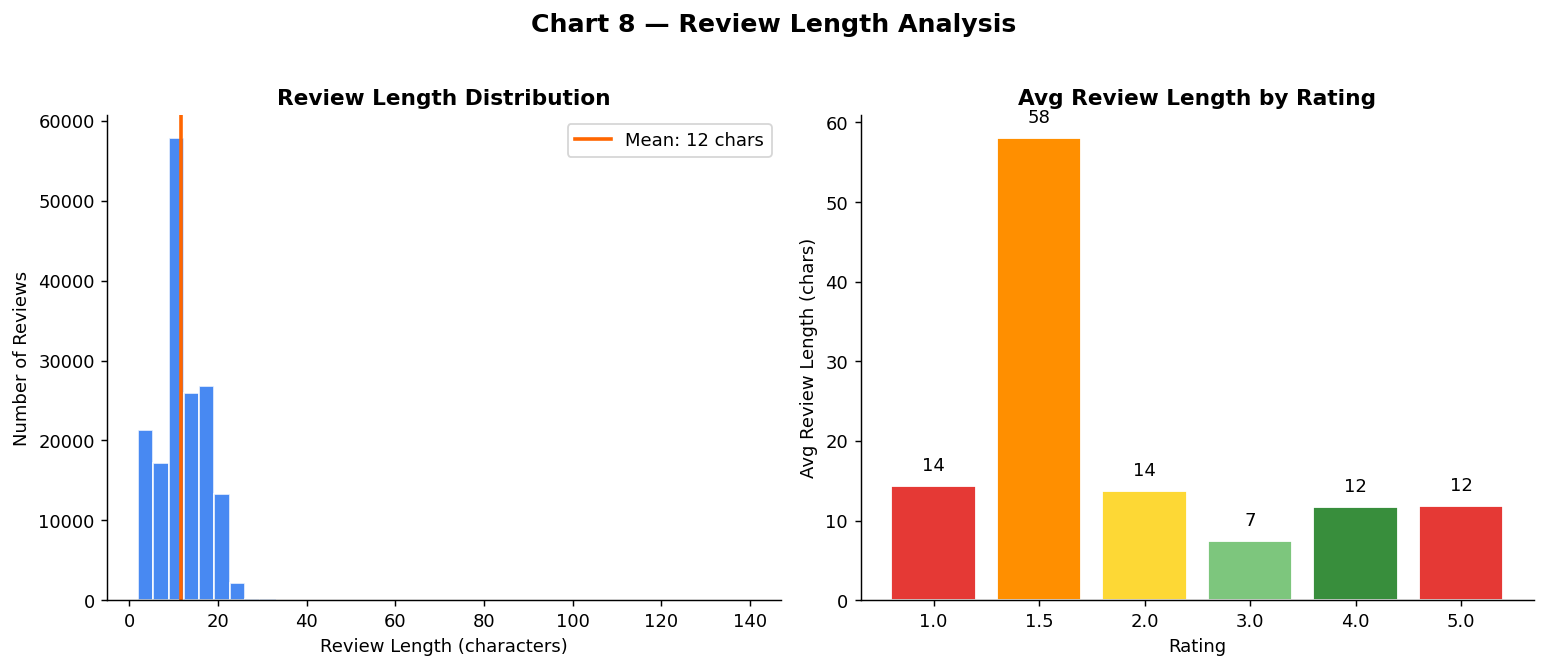

Observation: Longer reviews often come from dissatisfied (1-star) customers


In [49]:
# ── Chart 8 : Review Length Analysis ─────────────────────────────────────────
df["review_length"] = df[review_col].astype(str).apply(len)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].hist(df["review_length"][df["review_length"] < 500],
             bins=40, color=CLR_SECONDARY, edgecolor="white", alpha=0.85)
axes[0].set_xlabel("Review Length (characters)")
axes[0].set_ylabel("Number of Reviews")
axes[0].set_title("Review Length Distribution", fontsize=12, fontweight="bold")
axes[0].axvline(df["review_length"].mean(), color=CLR_PRIMARY, lw=2,
                label=f"Mean: {df['review_length'].mean():.0f} chars")
axes[0].legend()

# Avg review length by rating
avg_len_by_rating = df.groupby(rating_col)["review_length"].mean()
axes[1].bar(avg_len_by_rating.index.astype(str), avg_len_by_rating.values,
            color=["#E53935","#FF8F00","#FDD835","#7DC67D","#388E3C"], edgecolor="white")
axes[1].set_xlabel("Rating")
axes[1].set_ylabel("Avg Review Length (chars)")
axes[1].set_title("Avg Review Length by Rating", fontsize=12, fontweight="bold")
for i, v in enumerate(avg_len_by_rating.values):
    axes[1].text(i, v+2, f"{v:.0f}", ha="center", fontsize=10)

plt.suptitle("Chart 8 — Review Length Analysis", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig(f"{CHARTS_DIR}/chart_08_review_length.png", dpi=150, bbox_inches="tight")
plt.show()
print("Observation: Longer reviews often come from dissatisfied (1-star) customers")


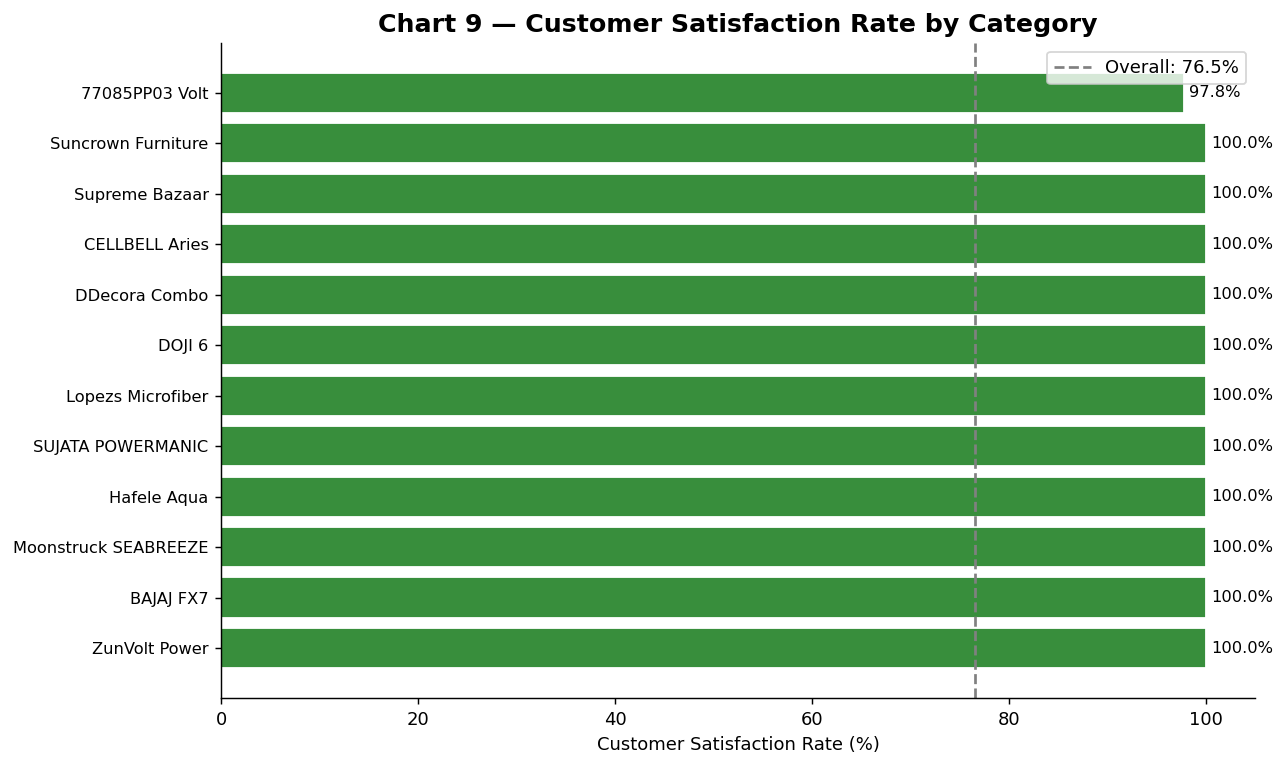

In [50]:
# ── Chart 9 : Satisfaction Rate by Category ──────────────────────────────────
# Satisfied = rating >= 4
df["Satisfied"] = (df[rating_col] >= 4).astype(int)
satisfaction = (df.groupby(cat_col)["Satisfied"]
                  .agg(["mean","count"])
                  .rename(columns={"mean":"Sat_Rate","count":"Total"})
                  .query("Total >= 10")
                  .sort_values("Sat_Rate", ascending=False)
                  .head(12))
satisfaction["Sat_Pct"] = satisfaction["Sat_Rate"] * 100

fig, ax = plt.subplots(figsize=(10, 6))
colors_sat = [CLR_ACCENT if v >= 70 else CLR_WARNING if v >= 50 else CLR_WARNING
              for v in satisfaction["Sat_Pct"]]
bars = ax.barh(range(len(satisfaction)), satisfaction["Sat_Pct"],
               color=colors_sat, edgecolor="white")
ax.set_yticks(range(len(satisfaction)))
ax.set_yticklabels([t[:30] for t in satisfaction.index], fontsize=9)
ax.set_xlabel("Customer Satisfaction Rate (%)")
ax.set_title("Chart 9 — Customer Satisfaction Rate by Category",
             fontsize=14, fontweight="bold")
ax.axvline(df["Satisfied"].mean()*100, color="gray", lw=1.5, linestyle="--",
           label=f"Overall: {df['Satisfied'].mean()*100:.1f}%")
ax.legend()
for i, v in enumerate(satisfaction["Sat_Pct"]):
    ax.text(v+0.5, i, f"{v:.1f}%", va="center", fontsize=9)
plt.tight_layout()
plt.savefig(f"{CHARTS_DIR}/chart_09_satisfaction_rate.png", dpi=150, bbox_inches="tight")
plt.show()


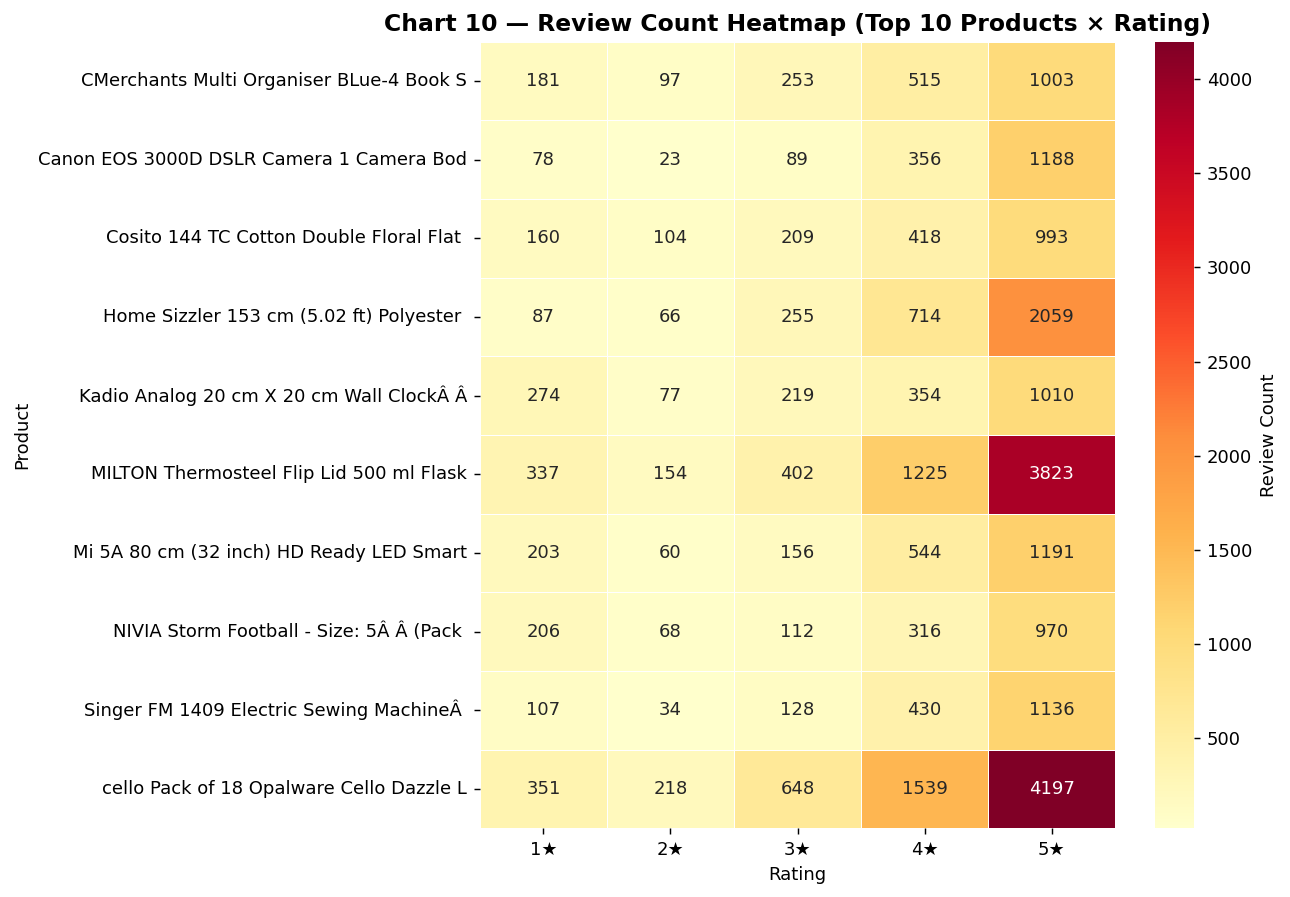

✓ All 10 EDA charts saved to ./charts/


In [51]:
# ── Chart 10 : Rating Heatmap — Top Products vs Rating Stars ────────────────
top10_prods = df[product_col].value_counts().head(10).index.tolist()
heat_data   = (df[df[product_col].isin(top10_prods)]
                 .groupby([product_col, rating_col])
                 .size().unstack(fill_value=0))
heat_data.columns = [f"{int(c)}★" for c in heat_data.columns]
heat_data.index   = [t[:40] for t in heat_data.index]

fig, ax = plt.subplots(figsize=(10, 7))
sns.heatmap(heat_data, annot=True, fmt="d", cmap="YlOrRd",
            linewidths=0.5, linecolor="white",
            cbar_kws={"label": "Review Count"}, ax=ax)
ax.set_title("Chart 10 — Review Count Heatmap (Top 10 Products × Rating)",
             fontsize=13, fontweight="bold")
ax.set_xlabel("Rating")
ax.set_ylabel("Product")
plt.tight_layout()
plt.savefig(f"{CHARTS_DIR}/chart_10_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()
print("✓ All 10 EDA charts saved to ./charts/")


##  Section 7 — Customer Insights & Summary Report
> **Task:** Generate key insights from the Flipkart data analysis.

In [52]:
# ── Product Sentiment Segmentation ───────────────────────────────────────────
prod_summary = df.groupby(product_col).agg(
    Total_Reviews = (rating_col, "count"),
    Avg_Rating    = (rating_col, "mean"),
    Satisfaction  = ("Satisfied", "mean")
).query("Total_Reviews >= 5").round(2)

def product_tier(row):
    if row["Avg_Rating"] >= 4.5 and row["Total_Reviews"] >= 20:
        return " Top Rated"
    elif row["Avg_Rating"] >= 4.0:
        return " Good"
    elif row["Avg_Rating"] >= 3.0:
        return " Average"
    else:
        return " Poor"

prod_summary["Tier"] = prod_summary.apply(product_tier, axis=1)
tier_counts = prod_summary["Tier"].value_counts()

print("=== PRODUCT TIER BREAKDOWN ===")
for tier, count in tier_counts.items():
    pct = count / len(prod_summary) * 100
    print(f"  {tier:<20}: {count:>5} products ({pct:.1f}%)")

prod_summary.to_csv(f"{OUTPUTS_DIR}/product_summary.csv")
print(f"\n Saved → {OUTPUTS_DIR}/product_summary.csv")


=== PRODUCT TIER BREAKDOWN ===
   Good               :   378 products (46.7%)
   Average            :   322 products (39.8%)
   Top Rated          :    70 products (8.6%)
   Poor               :    40 products (4.9%)

 Saved → ./outputs/product_summary.csv


In [53]:
# ── Final Summary Report ──────────────────────────────────────────────────────
print("=" * 60)
print("    E-COMMERCE ANALYSIS (FLIPKART/INDIA) — KEY INSIGHTS")
print("=" * 60)

print(f"\n   Dataset Overview")
print(f"     Total reviews    : {len(df):,}")
print(f"     Unique products  : {df[product_col].nunique():,}")
print(f"     Unique categories: {df[cat_col].nunique():,}")

print(f"\n   Rating Insights")
print(f"     Average rating   : {df[rating_col].mean():.2f} / 5")
print(f"     5-star reviews   : {(df[rating_col]==5).sum():,} ({(df[rating_col]==5).mean()*100:.1f}%)")
print(f"     1-star reviews   : {(df[rating_col]==1).sum():,} ({(df[rating_col]==1).mean()*100:.1f}%)")
print(f"     Satisfied (≥4★)  : {df['Satisfied'].mean()*100:.1f}% of customers")

print(f"\n   Shopping Patterns")
print(f"     Most reviewed product : {df[product_col].value_counts().index[0][:50]}")
print(f"     Top category          : {df[cat_col].value_counts().index[0]}")
print(f"     Avg review length     : {df['review_length'].mean():.0f} characters")

print(f"\n   Product Quality")
for tier, count in tier_counts.items():
    pct = count / len(prod_summary) * 100
    print(f"     {tier:<22}: {count:>5} products ({pct:.1f}%)")

print(f"\n  Outputs → ./outputs/")
print(f"   Charts  → ./charts/")
print("=" * 60)


    E-COMMERCE ANALYSIS (FLIPKART/INDIA) — KEY INSIGHTS

   Dataset Overview
     Total reviews    : 165,010
     Unique products  : 811
     Unique categories: 614

   Rating Insights
     Average rating   : 4.07 / 5
     5-star reviews   : 93,058 (56.4%)
     1-star reviews   : 18,782 (11.4%)
     Satisfied (≥4★)  : 76.5% of customers

   Shopping Patterns
     Most reviewed product : cello Pack of 18 Opalware Cello Dazzle Lush Fiesta
     Top category          : cello Pack
     Avg review length     : 12 characters

   Product Quality
      Good                 :   378 products (46.7%)
      Average              :   322 products (39.8%)
      Top Rated            :    70 products (8.6%)
      Poor                 :    40 products (4.9%)

  Outputs → ./outputs/
   Charts  → ./charts/
